# Finding When K curve is Linear and predict K curves for any cost factor


In [60]:
import numpy as np
import pickle

from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt, log, e, pi
from statistics import NormalDist

# constants
N_16 = 2 ** 16
NUM_COLORS = 20
LINE_STYLES = ['solid', 'dashed', 'dashdot', 'dotted']
NUM_STYLES = len(LINE_STYLES)

In [52]:
def plot_all_kj(results, labels):
    # to get different colours
    sns.reset_orig()  # get default matplotlib styles back
    clrs = sns.color_palette('husl', n_colors=NUM_COLORS)  # a list of RGB tuples

    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)

    # [K_js, m_0, final_cost, m_values]
    for i, result in enumerate(results):
        label = labels[i]
        lines = ax.plot(result, label=f"Factor = {label}")
        lines[0].set_color(clrs[i])
        lines[0].set_linestyle(LINE_STYLES[i % NUM_STYLES])

        # annotate the m_t value for each line in the plot
        # y = result[-1]  # get the last K_j value to position text

        # ax.annotate(round(result[3][-1]),
        #             xy=(1, y),
        #             xytext=(6, 0),
        #             color=clrs[i],
        #             xycoords=ax.get_yaxis_transform(), textcoords="offset points", size=8, va="center")

    ax.set_ylabel(r"$K_{j}$", **{"fontname": "Times New Roman", "style": "italic", "fontsize": 12, "labelpad": -2})
    ax.set_xlabel("j", **{"fontname": "Times New Roman", "style": "italic", "fontsize": 12})


    plt.legend(loc="upper left", bbox_to_anchor=(1.08, 1))
    plt.show()

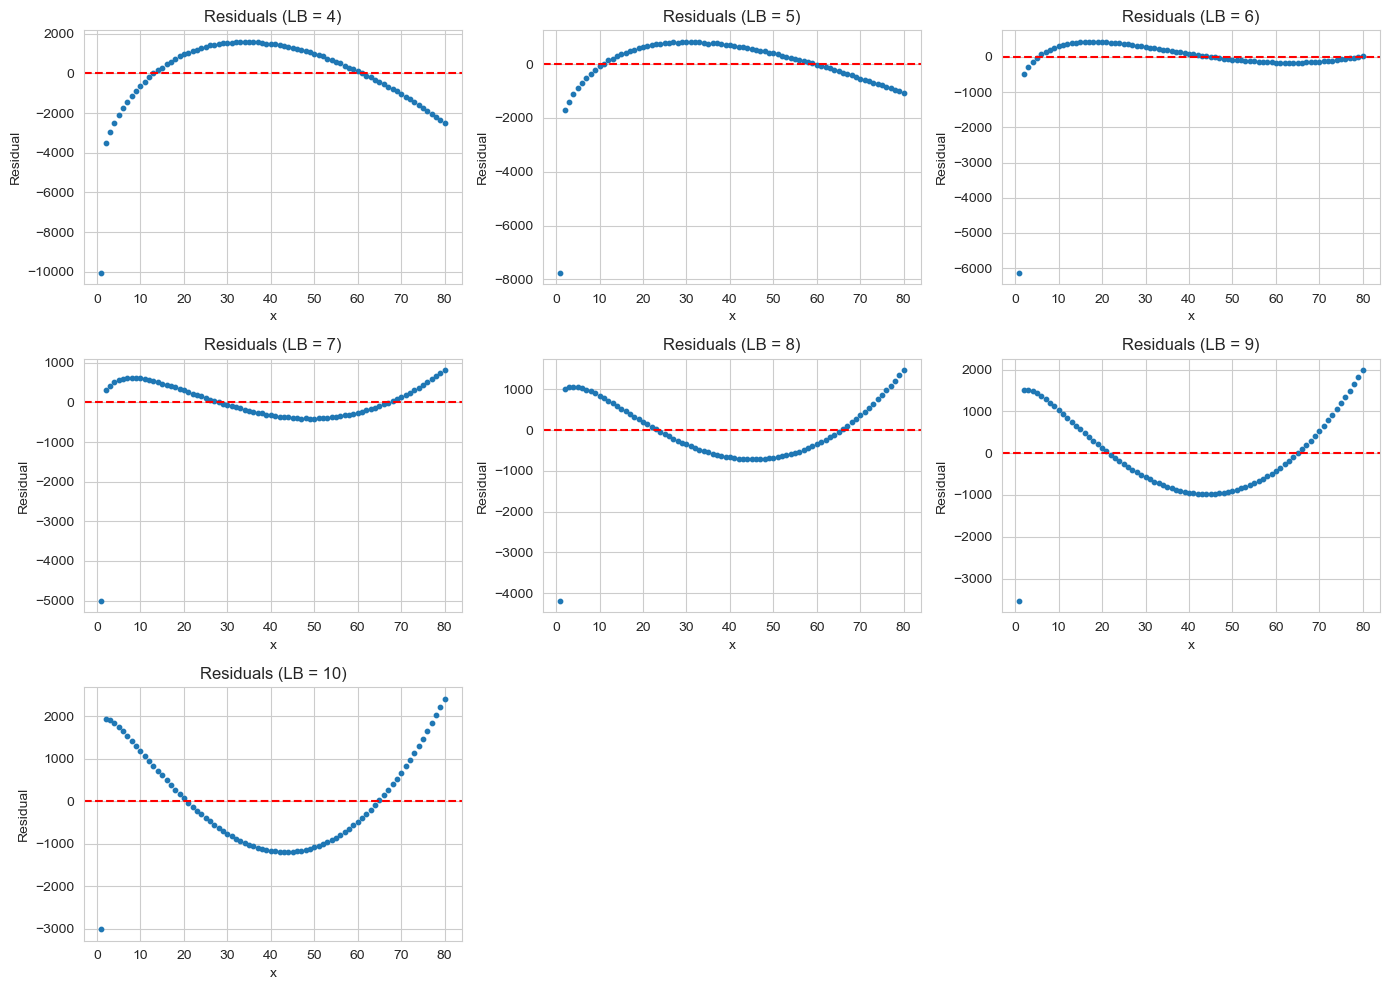

Lower bound 4: R² = 0.9978, MSE = 3041451.8347
Lower bound 5: R² = 0.9993, MSE = 1160451.9525
Lower bound 6: R² = 0.9997, MSE = 523525.6604
Lower bound 7: R² = 0.9997, MSE = 454681.8568
Lower bound 8: R² = 0.9996, MSE = 635346.9937
Lower bound 9: R² = 0.9995, MSE = 915239.8533
Lower bound 10: R² = 0.9993, MSE = 1238954.6953


In [26]:
def find_linear_curve():
    # import the data
    with open('linear_curve_collation.pickle', 'rb') as f:
        data = pickle.load(f)
        
    # define the lower bounds
    bounds = [4, 5, 6, 7, 8, 9, 10]
        
    # an array of 1 - 80 for the number of columns (X AXIS)
    xaxis = np.arange(1, len(data[0][0]) + 1)
    
    # get the curves in one array as tuples
    curves = []
    
    for i in range(len(data)):
        curves.append((xaxis, data[i][0]))
    
    results = []
    
    # Plot setup
    plt.figure(figsize=(14, 10))
    
    # loop through the curves and fit a linear regression model
    for i, (x, y) in enumerate(curves):
        x = x.reshape(-1, 1)
        model = LinearRegression().fit(x, y)
        y_pred = model.predict(x)
    
        r2 = r2_score(y, y_pred)
        mse = mean_squared_error(y, y_pred)
        residuals = y - y_pred
    
        results.append((i+1, r2, mse))
        
        # Plot residuals
        plt.subplot(3, 3, i + 1)  # Adjust grid based on how many curves you have
        plt.scatter(x, residuals, s=10)
        plt.axhline(y=0, color='red', linestyle='--')
        plt.title(f'Residuals (LB = {bounds[i]})')
        plt.xlabel('x')
        plt.ylabel('Residual')
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Show results
    for curve_id, r2, mse in results:
        print(f"Lower bound {bounds[curve_id - 1]}: R² = {r2:.4f}, MSE = {mse:.4f}")
        
# Call the function to find linear curves
find_linear_curve()


In [27]:
# Do the same  for the different curves with a lower bound of 7
with open('lower_bound_7_curves.pickle', 'rb') as f:
    data = pickle.load(f)

# define the cost factors 
cost_factors = list(range(5, 101, 5))

# an array of 1 - 80 for the number of columns
xaxis = np.arange(1, len(data[0][0]) + 1)

# get the curves in one array as tuples
curves = []

for i in range(len(data)):
    curves.append((xaxis, data[i][0]))
    
# curves in format [curve_id, r2, mse, slope, intercept]
results = []

# loop through the curves and fit a linear regression model
for i, (x, y) in enumerate(curves):
    x = x.reshape(-1, 1)
    model = LinearRegression().fit(x, y)
    y_pred = model.predict(x)

    r2 = r2_score(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    
    slope = model.coef_[0]
    intercept = model.intercept_

    results.append((i+1, r2, mse, slope, intercept))
    

# Show results
for curve_id, r2, mse, slope, intercept in results:
    print(f"Cost factor {cost_factors[curve_id - 1]}: R² = {r2:.4f}, MSE = {mse:.4f}, Line: y = {slope:.4f}x + {intercept:.4f}")


Cost factor 5: R² = 0.9997, MSE = 766.2759, Line: y = 73.5685x + 138.3478
Cost factor 10: R² = 0.9997, MSE = 3924.8041, Line: y = 166.3724x + 304.6716
Cost factor 15: R² = 0.9997, MSE = 9496.1331, Line: y = 258.5147x + 469.9303
Cost factor 20: R² = 0.9997, MSE = 16777.0097, Line: y = 350.8294x + 624.4658
Cost factor 25: R² = 0.9997, MSE = 27882.6165, Line: y = 441.6064x + 800.2001
Cost factor 30: R² = 0.9997, MSE = 40533.1588, Line: y = 532.8187x + 963.8703
Cost factor 35: R² = 0.9997, MSE = 55640.6830, Line: y = 623.8211x + 1127.5425
Cost factor 40: R² = 0.9997, MSE = 73029.3693, Line: y = 714.6760x + 1290.7326
Cost factor 45: R² = 0.9997, MSE = 92745.0273, Line: y = 805.3908x + 1453.7258
Cost factor 50: R² = 0.9996, MSE = 206668.2227, Line: y = 939.0768x + 514.5269
Cost factor 55: R² = 0.9997, MSE = 139137.6111, Line: y = 986.4715x + 1779.0187
Cost factor 60: R² = 0.9996, MSE = 252349.0871, Line: y = 1128.9661x + 617.6236
Cost factor 65: R² = 0.9997, MSE = 194778.6989, Line: y = 1167

In [28]:
# store results in a pickle file
# with open('lb7_eq_results.pickle', 'wb') as f:
#     pickle.dump(results, f)

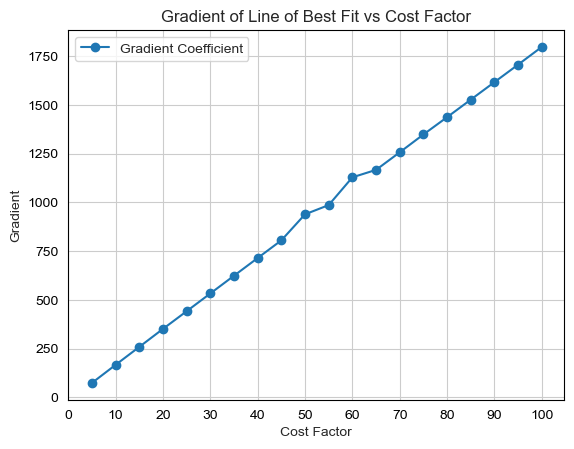

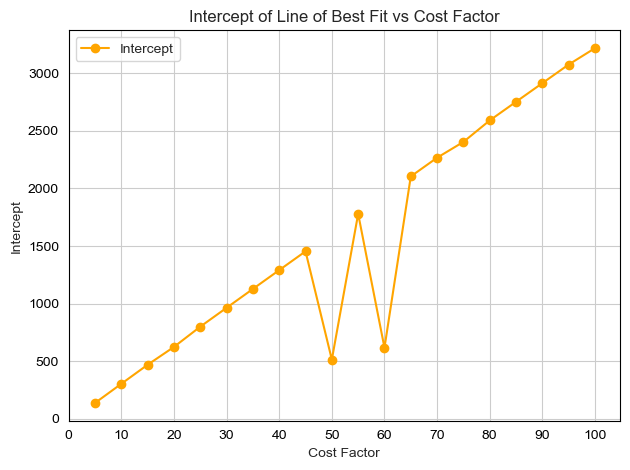

In [29]:
slopes = [result[3] for result in results]
intercepts = [result[4] for result in results]

def plot_coefficients(slopes, intercepts, cost_factors):

    # plot slope and intercept v cst factor to see their trends 
    
    # plot slope v cost factor
    plt.plot(cost_factors, slopes, marker='o', label='Gradient Coefficient')
    
    plt.xlabel('Cost Factor')
    plt.ylabel('Gradient')
    plt.title('Gradient of Line of Best Fit vs Cost Factor')
     
    # Displaying the legend
    plt.legend()
    
    # Get current axis
    ax = plt.gca()
    
    # Set x-ticks in increments of 10
    ax.set_xticks(range(0, max(cost_factors)+10, 10))
    
    # Set all spines (box edges) to black
    for spine in ax.spines.values():
        spine.set_color('black')
    
    # Set tick parameters to black
    ax.tick_params(axis='both', colors='black')
    
    # Optionally turn off grid if it's on
    ax.grid(True)
     
    # Display the plot
    plt.show()
    
    # # plot intercept v cost factor
    plt.plot(cost_factors, intercepts, marker='o', color='orange', label='Intercept')
    
    plt.title('Intercept of Line of Best Fit vs Cost Factor')
    plt.xlabel('Cost Factor')
    plt.ylabel('Intercept')
    
    plt.legend()
    plt.tight_layout()
    # Get current axis
    ax = plt.gca()
    
    # Set x-ticks in increments of 10
    ax.set_xticks(range(0, max(cost_factors)+10, 10))
    
    # Set all spines (box edges) to black
    for spine in ax.spines.values():
        spine.set_color('black')
    
    # Set tick parameters to black
    ax.tick_params(axis='both', colors='black')
    
    # Optionally turn off grid if it's on
    ax.grid(True)
     
    # Display the plot
    plt.show()
    
# Call the function to plot coefficients
plot_coefficients(slopes, intercepts, cost_factors)


Find a way to model the coefficients as a function of the cost factor.

In [30]:
# np arrays
cost_factors = np.array(cost_factors)
slopes = np.array(slopes)
intercepts = np.array(intercepts)

# Create mask to exclude cost factors 50 and 60 - anomalies
mask = (cost_factors != 50) & (cost_factors != 60)

# Filter the arrays
cost_factors_filtered = cost_factors[mask]
slopes_filtered = slopes[mask]
intercepts_filtered = intercepts[mask]

# Fit slope vs cost factor
slope_model = LinearRegression().fit(cost_factors_filtered.reshape(-1, 1), slopes_filtered)
slope_m = slope_model.coef_[0]
slope_c = slope_model.intercept_

# Fit intercept vs cost factor
intercept_model = LinearRegression().fit(cost_factors_filtered.reshape(-1, 1), intercepts_filtered)
intercept_m = intercept_model.coef_[0]
intercept_c = intercept_model.intercept_

# print model
print(f"Gradient model: m(cost) = {slope_m:.4f} * cost + {slope_c:.4f}")
print(f"Intercept model: c(cost) = {intercept_m:.4f} * cost + {intercept_c:.4f}")

Gradient model: m(cost) = 18.1278 * cost + -12.4600
Intercept model: c(cost) = 32.5009 * cost + -15.6611


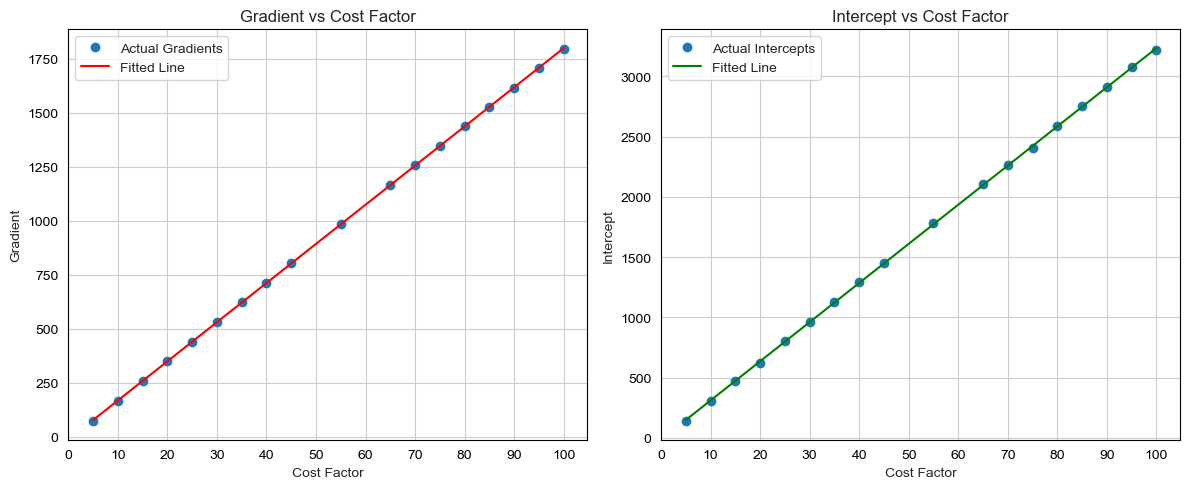

In [31]:
x_fit = np.linspace(5, 100, 500)

# Predicted lines
slope_fit = slope_model.predict(x_fit.reshape(-1, 1))
intercept_fit = intercept_model.predict(x_fit.reshape(-1, 1))

plt.figure(figsize=(12, 5))

# Slope
plt.subplot(1, 2, 1)
plt.plot(cost_factors_filtered, slopes_filtered, 'o', label='Actual Gradients')
plt.plot(x_fit, slope_fit, '-', label='Fitted Line', color='red')
plt.title("Gradient vs Cost Factor")
plt.xlabel("Cost Factor")
plt.ylabel("Gradient")
plt.grid(True)
plt.legend()
# Get current axis
ax = plt.gca()
# Set x-ticks in increments of 10
ax.set_xticks(range(0, max(cost_factors)+10, 10))
# Set all spines (box edges) to black
for spine in ax.spines.values():
    spine.set_color('black')
# Set tick parameters to black
ax.tick_params(axis='both', colors='black')

# Intercept
plt.subplot(1, 2, 2)
plt.plot(cost_factors_filtered, intercepts_filtered, 'o', label='Actual Intercepts')
plt.plot(x_fit, intercept_fit, '-', label='Fitted Line', color='green')
plt.title("Intercept vs Cost Factor")
plt.xlabel("Cost Factor")
plt.ylabel("Intercept")
plt.grid(True)
plt.legend()
# Get current axis
ax = plt.gca()
# Set x-ticks in increments of 10
ax.set_xticks(range(0, max(cost_factors)+10, 10))
# Set all spines (box edges) to black
for spine in ax.spines.values():
    spine.set_color('black')
# Set tick parameters to black
ax.tick_params(axis='both', colors='black')

plt.tight_layout()
plt.show()

In [32]:
# Save the models
# with open('slope_model.pickle', 'wb') as f:
#     pickle.dump(slope_model, f)
# with open('intercept_model.pickle', 'wb') as f:
#     pickle.dump(intercept_model, f)

# model a K-curve for lower bound 7 from any cost factor
def kcurve_7_from_cost(cost):
    m = slope_model.predict([[cost]])[0]
    c = intercept_model.predict([[cost]])[0]
    return f"y = {m:.4f}x + {c:.4f}"

print(kcurve_7_from_cost(100))

y = 1800.3211x + 3234.4293


### Evaluate the K curve model

In [33]:
# import the actual curves
with open('lower_bound_7_higher_cost_curves.pickle', 'rb') as f:
    actual_data = pickle.load(f)
    
# define the cost factors
cost_factors = [200, 500, 1000, 2000, 3000, 4000, 5000, 10000, 100000, 1000000]

# x-axis
xaxis = np.arange(1, len(actual_data[0][0]) + 1)

# for each factor
for i in range(len(cost_factors)):
    # get the actual K curve
    actual_curve = actual_data[i][0]

    # Predict line from model
    m = slope_model.predict([[cost_factors[i]]])[0]
    c = intercept_model.predict([[cost_factors[i]]])[0]
    y_pred = m * xaxis + c
    
    # Evaluate
    r2 = r2_score(actual_curve, y_pred)
    mse = mean_squared_error(actual_curve, y_pred)
    
    print(f"Evaluation for cost factor {cost_factors[i]}:  R² = {r2:.4f}  MSE = {mse:.4f}")
    

Evaluation for cost factor 200:  R² = 0.9995  MSE = 3227720.8395
Evaluation for cost factor 500:  R² = 0.9985  MSE = 63672186.8358
Evaluation for cost factor 1000:  R² = 0.9972  MSE = 470136942.9662
Evaluation for cost factor 2000:  R² = 0.9954  MSE = 3037410882.5305
Evaluation for cost factor 3000:  R² = 0.9941  MSE = 8637478725.1035
Evaluation for cost factor 4000:  R² = 0.9931  MSE = 17845299704.9023
Evaluation for cost factor 5000:  R² = 0.9830  MSE = 66179693570.0152
Evaluation for cost factor 10000:  R² = -4.5035  MSE = 21371322072378.5625
Evaluation for cost factor 100000:  R² = -1783.2740  MSE = 6928764061711232.0000
Evaluation for cost factor 1000000:  R² = -194646.1907  MSE = 755861762516215168.0000


In [34]:
# plot the number of endpoints as the cost factor increases
# endpoints = [actual_data[i][3][-1] for i in range(len(actual_data))]
# plt.figure(figsize=(12, 6))
# 
# plt.plot(cost_factors, endpoints, marker='o')

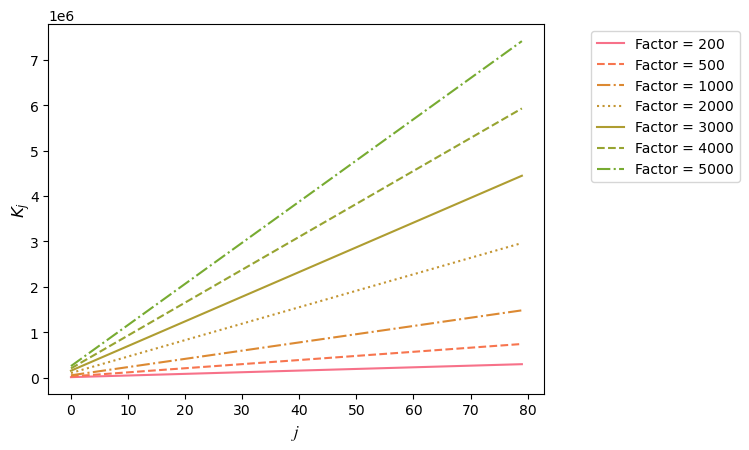

In [59]:
# plot the predicted K curve against the actual K curve

# store the predicted K curves
predicted = []
actual = []
for i in range(len(cost_factors)):
    # get the actual K curve
    actual_curve = actual_data[i][0]
    actual.append(actual_curve)

    # Predict line from model
    m = slope_model.predict([[cost_factors[i]]])[0]
    c = intercept_model.predict([[cost_factors[i]]])[0]
    y_pred = m * xaxis + c
    predicted.append(y_pred)
    

# plot the predicted K curves
plot_all_kj(predicted[:-3], cost_factors[:-3])


In [63]:
# Calculate the m_t for the predicted curves
def calculate_m_t(N, t, predicted_curve):
    m = predicted_curve[0]  # initial value of m
    
    for i in range(0, t):# iterate through the column
        # calculate k -> k has to be at least 1
        k = max(predicted_curve[i], 1)
        
        # Calculate E1 and E2
        E1 = (1-1/N) ** m
        E2 = (1-2/N) ** m
        average = N*(1 - E1)
        
        # check if the variance is positive, sometimes error happens because of float calculation on very small values
        if N*((N-1)*E2 + E1 - N*E1**2)<0:
            # if it is negative (error), set it to 0
            variance = 0
        else:
            # count the statistical variance of m_j+1 otherwise
            variance = sqrt(N*((N-1)*E2 + E1 - N*E1**2))
            
        # find the m_j+1
        m = average + NormalDist().inv_cdf((k - pi / 8) / (k - pi / 4 + 1)) * variance
        
    # return the final m_t
    return m

In [64]:
# calculate the m_t for the predicted curves
m_t = []
for i in range(len(predicted)):
    m_t.append(calculate_m_t(N_16, 80, predicted[i]))
    
# collate the m_t for the actual curves
m_t_actual = []
for i in range(len(actual)):
    m_t_actual.append(data[i][3][-1])
    
    
print("m_t for predicted curves: ", m_t)
print("m_t for actual curves: ", m_t_actual)


m_t for predicted curves:  [2331.589436469458, 2499.9905652172447, 2574.0300280088277, 2624.678784884356, 2648.0705881106273, 2662.8892147595034, 2673.6671022982314, 2705.032106349723, 2803.777431579918, 2897.7334902310154]
m_t for actual curves:  [2282.5221073851726, 2328.976230366839, 2353.355856051785, 2369.9370414429663, 2382.36673344332, 2392.3858569214794, 2400.7426561195753, 2407.9064858222046, 2414.171548975342, 2420.5385306190265]
